# Offline Tracklet Association for UAV Videos using VisDrone Dataset

This notebook implements a **classical**, non-deep-learning pipeline for **offline tracklet association** on the **VisDrone2019-MOT** dataset.

We will:
- Load the VisDrone2019-MOT dataset (annotations + sequences)
- Visualize bounding boxes and object IDs
- Build **short tracklets** using a simple center-based tracker
- Compute tracklet statistics and visualize them
- Implement **offline tracklet merging** using spatio-temporal proximity (and optionally simple appearance cues)
- Visualize final tracks and discuss limitations and possible improvements

**Note:** This notebook uses only classical techniques (no deep learning training) and is intended to run locally in VS Code with the Jupyter extension.

## 1. Imports and Setup

We assume the dataset exists in the following relative structure (relative to this notebook's directory):

```text
VisDrone2019-MOT-train/
    sequences/
    annotations/
```

If you place this notebook in `mlproj/`, then `VisDrone2019-MOT-train` should be a sibling folder of this notebook.

In [1]:
%pip install opencv-python numpy pandas matplotlib scipy
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install "numpy==1.26.4" "pandas==2.1.4" "matplotlib==3.8.4" "scipy==1.11.4" opencv-python
%pip install pandas numpy matplotlib scipy opencv-python scikit-learn joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import os
import random
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

%matplotlib inline

# Base dataset paths (relative to this notebook)
BASE_PATH = "VisDrone2019-MOT-train"
SEQ_DIR = os.path.join(BASE_PATH, "sequences")
ANN_DIR = os.path.join(BASE_PATH, "annotations")

print("Base path:", os.path.abspath(BASE_PATH))
print("Sequences dir:", os.path.abspath(SEQ_DIR))
print("Annotations dir:", os.path.abspath(ANN_DIR))

# Basic dataset sanity checks
seq_exists = os.path.isdir(SEQ_DIR)
ann_exists = os.path.isdir(ANN_DIR)
print("Sequences directory exists:", seq_exists)
print("Annotations directory exists:", ann_exists)

if seq_exists:
    seq_files = sorted([f for f in os.listdir(SEQ_DIR) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv', '.jpg', '.png')) or os.path.isdir(os.path.join(SEQ_DIR, f))])
else:
    seq_files = []

if ann_exists:
    ann_files = sorted([f for f in os.listdir(ANN_DIR) if f.lower().endswith('.txt')])
else:
    ann_files = []

print(f"Found {len(seq_files)} sequence entries in 'sequences/'")
print(f"Found {len(ann_files)} annotation files in 'annotations/'")

Base path: c:\Users\Admin\Downloads\offline_tracklet_merging_visdrone_val\VisDrone2019-MOT-train
Sequences dir: c:\Users\Admin\Downloads\offline_tracklet_merging_visdrone_val\VisDrone2019-MOT-train\sequences
Annotations dir: c:\Users\Admin\Downloads\offline_tracklet_merging_visdrone_val\VisDrone2019-MOT-train\annotations
Sequences directory exists: True
Annotations directory exists: True
Found 56 sequence entries in 'sequences/'
Found 56 annotation files in 'annotations/'


## 2. Understanding the Dataset

The VisDrone MOT annotation format is typically given as a CSV (comma-separated) file with the following columns:

```text
frame,id,x,y,width,height,score,class,visibility,occlusion
```

- **frame**: Frame index (1-based in VisDrone; we will keep it as given but can convert to 0-based if desired)
- **id**: Object track ID (provided by dataset; we will ignore it when building our own tracklets, but we can use it for reference/visualization)
- **x, y, width, height**: Bounding box top-left coordinates and size
- **score**: Detection confidence score
- **class**: Object class
- **visibility, occlusion**: Visibility/occlusion annotations

We define a helper function `read_annotation_file(path)` that returns a `pandas.DataFrame` with appropriately named columns.

In [3]:
def read_annotation_file(path: str) -> pd.DataFrame:
    """Read a VisDrone MOT annotation file into a pandas DataFrame.

    Expected format per line:
    frame,id,x,y,width,height,score,class,visibility,occlusion
    """
    cols = [
        "frame",
        "id",
        "x",
        "y",
        "width",
        "height",
        "score",
        "class",
        "visibility",
        "occlusion",
    ]
    df = pd.read_csv(path, header=None, names=cols)
    return df

if ann_files:
    sample_ann_path = os.path.join(ANN_DIR, ann_files[0])
    print("Sample annotation file:", sample_ann_path)
    df_sample = read_annotation_file(sample_ann_path)
    display(df_sample.head())
else:
    print("No annotation files found. Please check that 'VisDrone2019-MOT-train/annotations' exists and contains .txt files.")

Sample annotation file: VisDrone2019-MOT-train\annotations\uav0000013_00000_v.txt


,frame,id,x,y,width,height,score,class,visibility,occlusion
0,1,0,593,43,174,190,0,0,0,0
1,2,0,592,43,174,189,0,0,0,0
2,3,0,592,43,174,189,0,0,0,0
3,4,0,592,43,174,189,0,0,0,0
4,5,0,592,43,174,189,0,0,0,0


## 3. Visualize Bounding Boxes

We will:

- Pick a random sequence and its corresponding annotation file.
- Load a few frames (e.g., first 3–5 frames) using OpenCV.
- Draw bounding boxes and object IDs from the annotation file.
- Display them with Matplotlib (which expects RGB images, so we will convert from BGR to RGB).

The implementation tries to handle two common VisDrone layouts for `sequences/`:

1. **Video files** (e.g., `.mp4`) per sequence
2. **Image folders** per sequence (frames stored as `imgXXXXX.jpg` or similar)

We will write helper functions to:
- Map an annotation filename to a sequence path
- Load a given frame index from that sequence
- Draw annotations on a frame

Chosen annotation: uav0000013_00000_v.txt
Matching sequence entry: uav0000013_00000_v


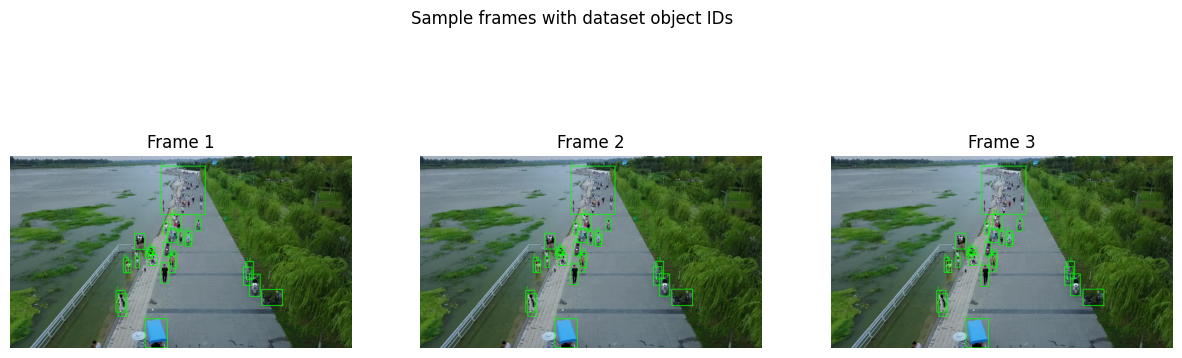

In [4]:
def get_sequence_name_from_ann(ann_filename: str) -> str:
    """Derive sequence name from annotation filename.

    VisDrone often uses matching names between annotations and sequences, e.g.:
    - annotations: 'uav0000013_00000_v.txt'
    - sequences:  'uav0000013_00000_v.mp4' or 'uav0000013_00000_v/'
    """
    base = os.path.splitext(ann_filename)[0]
    return base


def list_sequence_frames(seq_entry: str):
    """Return a list-like of frame sources for a sequence.

    If `seq_entry` is a directory: return sorted image file paths.
    If it's a video file: return the video path (we'll access frames by index via OpenCV).
    """
    seq_path = os.path.join(SEQ_DIR, seq_entry)
    if os.path.isdir(seq_path):
        imgs = [
            os.path.join(seq_path, f)
            for f in os.listdir(seq_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ]
        imgs = sorted(imgs)
        return imgs
    else:
        return [seq_path]


def load_frame_from_sequence(seq_entry: str, frame_idx: int):
    """Load a frame (1-based frame index as in annotations) from a sequence.

    Handles either image folders or video files.
    Returns a BGR image (as from cv2) or None if not available.
    """
    seq_path = os.path.join(SEQ_DIR, seq_entry)
    if os.path.isdir(seq_path):
        imgs = list_sequence_frames(seq_entry)
        idx0 = frame_idx - 1
        if 0 <= idx0 < len(imgs):
            img = cv2.imread(imgs[idx0])
            return img
        else:
            return None
    else:
        cap = cv2.VideoCapture(seq_path)
        if not cap.isOpened():
            return None
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx - 1)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            return None
        return frame


def draw_bboxes_on_frame(frame_bgr, ann_df_frame, use_dataset_ids: bool = True):
    """Draw bounding boxes and IDs on a frame.

    If `use_dataset_ids` is True, uses dataset-provided `id`; otherwise expects a `track_id` column.
    """
    img = frame_bgr.copy()
    for _, row in ann_df_frame.iterrows():
        x, y, w, h = int(row["x"]), int(row["y"]), int(row["width"]), int(row["height"])
        if use_dataset_ids:
            oid = int(row["id"])
        else:
            oid = int(row["track_id"])
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(
            img,
            str(oid),
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb


def pick_random_sequence_and_annotation():
    """Pick a random annotation file and try to find a matching sequence entry.

    Returns (ann_filename, seq_entry) or (None, None) if nothing found.
    """
    if not ann_files:
        return None, None
    
    candidates = ann_files.copy()
    random.shuffle(candidates)

    seq_entries = set(os.listdir(SEQ_DIR)) if os.path.isdir(SEQ_DIR) else set()

    for ann_f in candidates:
        seq_name = get_sequence_name_from_ann(ann_f)
        # Try exact directory or file match
        possible_matches = [
            seq_name,
            seq_name + ".mp4",
            seq_name + ".avi",
            seq_name + ".mov",
            seq_name + ".mkv",
        ]
        for pm in possible_matches:
            if pm in seq_entries:
                return ann_f, pm
    return None, None


# Demonstrate visualization for a few frames
ann_filename, seq_entry = pick_random_sequence_and_annotation()
if ann_filename is None:
    print("Could not find a matching sequence/annotation pair. Please check dataset consistency.")
else:
    print("Chosen annotation:", ann_filename)
    print("Matching sequence entry:", seq_entry)
    ann_path = os.path.join(ANN_DIR, ann_filename)
    df_ann = read_annotation_file(ann_path)
    
    # Get a few unique frame indices
    unique_frames = sorted(df_ann["frame"].unique())
    n_show = min(3, len(unique_frames))
    frames_to_show = unique_frames[:n_show]
    
    plt.figure(figsize=(15, 5))
    for i, fidx in enumerate(frames_to_show, start=1):
        frame_bgr = load_frame_from_sequence(seq_entry, int(fidx))
        if frame_bgr is None:
            continue
        df_f = df_ann[df_ann["frame"] == fidx]
        img_rgb = draw_bboxes_on_frame(frame_bgr, df_f, use_dataset_ids=True)
        plt.subplot(1, n_show, i)
        plt.imshow(img_rgb)
        plt.title(f"Frame {fidx}")
        plt.axis("off")
    plt.suptitle("Sample frames with dataset object IDs")
    plt.show()

## 4. Build Tracklets (Simple Center-Based Tracker)

We now implement a simple **online tracker** that builds tracklets frame by frame using only bounding box centers and Euclidean distance.

Algorithm outline:

1. For each frame in temporal order:
   - For each detection, compute its bounding box center.
   - Compare with centers of active tracklets from the previous frame.
   - Use **Euclidean distance** to match detections to tracklets.
   - If the minimum distance is below a threshold, assign the detection to that tracklet.
   - Otherwise, start a new tracklet.
2. Tracklet structure:

```python
tracklet = {
    'track_id': int,
    'frames': [frame indices],
    'boxes': [(x, y, w, h), ...],
    'centers': [(cx, cy), ...],
    'last_center': (cx, cy),
    'last_frame': frame_idx,
}
```

We will run this on the randomly chosen sequence/annotation pair.

In [5]:
def bbox_center(x, y, w, h):
    return (x + w / 2.0, y + h / 2.0)


def build_tracklets(df_ann: pd.DataFrame, dist_threshold: float = 50.0):
    """Build simple center-based tracklets from annotations.

    `dist_threshold` is in pixels.
    Returns a list of tracklet dicts.
    """
    tracklets = []
    next_track_id = 1

    # Map from active track_id to its last center and frame
    active_tracklets = {}

    for frame_idx in sorted(df_ann["frame"].unique()):
        df_f = df_ann[df_ann["frame"] == frame_idx]

        detections = []
        for _, row in df_f.iterrows():
            x, y, w, h = float(row["x"]), float(row["y"]), float(row["width"]), float(row["height"])
            cx, cy = bbox_center(x, y, w, h)
            detections.append({
                "bbox": (x, y, w, h),
                "center": (cx, cy),
            })

        if not active_tracklets:
            # Start a new tracklet for each detection
            for det in detections:
                t = {
                    "track_id": next_track_id,
                    "frames": [frame_idx],
                    "boxes": [det["bbox"]],
                    "centers": [det["center"]],
                    "last_center": det["center"],
                    "last_frame": frame_idx,
                }
                tracklets.append(t)
                active_tracklets[next_track_id] = t
                next_track_id += 1
        else:
            # Attempt to match detections to active tracklets
            unmatched_detects = list(range(len(detections)))
            # Simple greedy nearest-neighbor matching
            for tid, t in list(active_tracklets.items()):
                if not unmatched_detects:
                    break
                last_cx, last_cy = t["last_center"]
                best_idx = None
                best_dist = None
                for di in unmatched_detects:
                    cx, cy = detections[di]["center"]
                    d = distance.euclidean((last_cx, last_cy), (cx, cy))
                    if best_dist is None or d < best_dist:
                        best_dist = d
                        best_idx = di
                if best_idx is not None and best_dist is not None and best_dist <= dist_threshold:
                    det = detections[best_idx]
                    t["frames"].append(frame_idx)
                    t["boxes"].append(det["bbox"])
                    t["centers"].append(det["center"])
                    t["last_center"] = det["center"]
                    t["last_frame"] = frame_idx
                    unmatched_detects.remove(best_idx)
                else:
                    # If this tracklet cannot be matched in this frame, we keep it but it may be merged later.
                    pass

            # Start new tracklets for remaining detections
            for di in unmatched_detects:
                det = detections[di]
                t = {
                    "track_id": next_track_id,
                    "frames": [frame_idx],
                    "boxes": [det["bbox"]],
                    "centers": [det["center"]],
                    "last_center": det["center"],
                    "last_frame": frame_idx,
                }
                tracklets.append(t)
                active_tracklets[next_track_id] = t
                next_track_id += 1

    return tracklets


if ann_filename is not None:
    print("Building tracklets for:", ann_filename)
    tracklets_initial = build_tracklets(df_ann, dist_threshold=60.0)
    print("Initial number of tracklets:", len(tracklets_initial))
else:
    tracklets_initial = []
    print("No sequence selected earlier; cannot build tracklets.")

Building tracklets for: uav0000013_00000_v.txt
Initial number of tracklets: 60


## 5. Tracklet Statistics

We compute basic statistics over the generated tracklets:

- Total number of tracklets
- Length of each tracklet (number of frames it spans, i.e., number of detections)
- Average and median tracklet length
- Longest and shortest tracklet lengths
- Histogram of tracklet lengths

Initial tracklet statistics:
  total: 60
  avg: 143.56666666666666
  median: 157.0
  max: 269
  min: 1


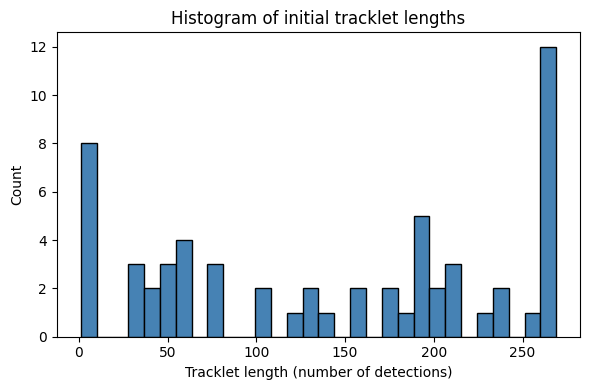

In [6]:
def tracklet_lengths(tracklets):
    return [len(t["frames"]) for t in tracklets]


def compute_tracklet_stats(tracklets):
    lengths = tracklet_lengths(tracklets)
    if not lengths:
        return {
            "total": 0,
            "avg": 0.0,
            "median": 0.0,
            "max": 0,
            "min": 0,
        }
    total = len(lengths)
    avg = float(np.mean(lengths))
    median = float(np.median(lengths))
    max_len = int(np.max(lengths))
    min_len = int(np.min(lengths))
    return {
        "total": total,
        "avg": avg,
        "median": median,
        "max": max_len,
        "min": min_len,
    }


stats_initial = compute_tracklet_stats(tracklets_initial)
print("Initial tracklet statistics:")
for k, v in stats_initial.items():
    print(f"  {k}: {v}")

if stats_initial["total"] > 0:
    plt.figure(figsize=(6, 4))
    plt.hist(tracklet_lengths(tracklets_initial), bins=30, color="steelblue", edgecolor="black")
    plt.xlabel("Tracklet length (number of detections)")
    plt.ylabel("Count")
    plt.title("Histogram of initial tracklet lengths")
    plt.tight_layout()
    plt.show()
else:
    print("No tracklets to visualize.")

## 6. Tracklet Visualization

To see how our simple tracker behaves, we overlay **track IDs** (from our own tracklets) on the frames.

Steps:

- Build a per-frame mapping from detections to track IDs based on the tracklets.
- For a chosen sequence, draw bounding boxes and label them with the **tracklet ID**.
- Display the first 10 frames (or fewer if the sequence has fewer).

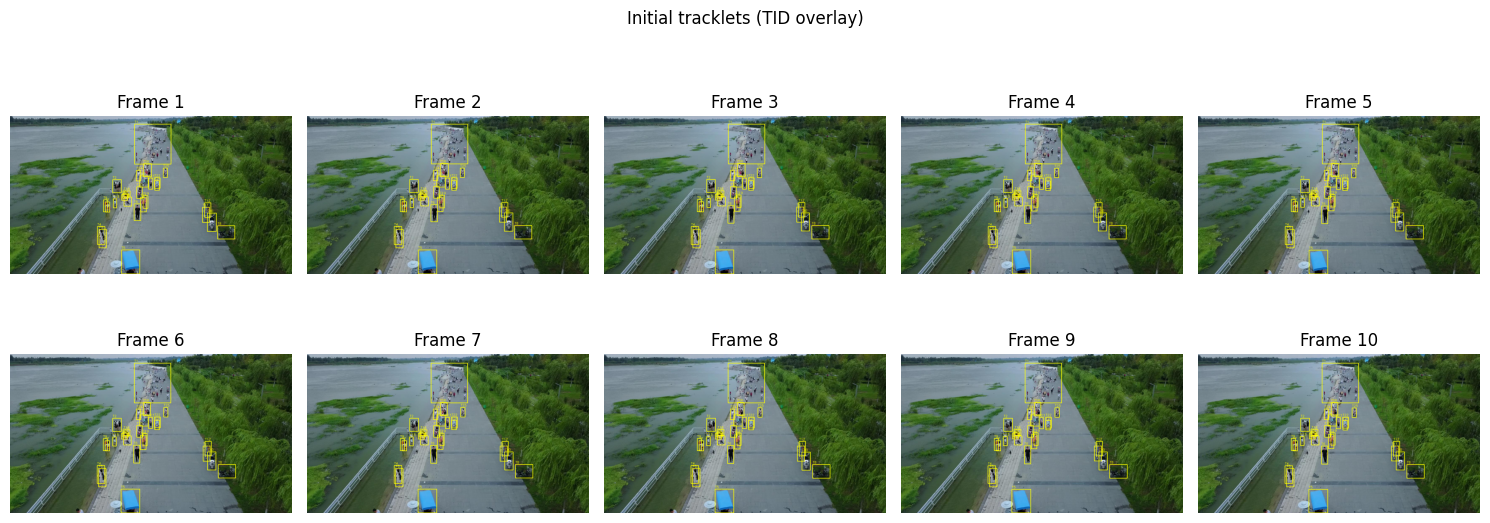

In [7]:
def build_frame_to_track_detections(tracklets):
    """Build mapping: frame_idx -> list of (track_id, bbox)."""
    frame_map = defaultdict(list)
    for t in tracklets:
        tid = t["track_id"]
        for f, bbox in zip(t["frames"], t["boxes"]):
            frame_map[f].append((tid, bbox))
    return frame_map


def draw_tracklets_on_frame(frame_bgr, frame_idx, frame_to_tracks):
    img = frame_bgr.copy()
    for tid, bbox in frame_to_tracks.get(frame_idx, []):
        x, y, w, h = map(int, bbox)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
        cv2.putText(
            img,
            f"T{tid}",
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
            cv2.LINE_AA,
        )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb


if tracklets_initial and ann_filename is not None:
    frame_to_tracks_initial = build_frame_to_track_detections(tracklets_initial)
    all_frames = sorted(frame_to_tracks_initial.keys())
    if not all_frames:
        print("No frames present in tracklets.")
    else:
        max_frames_to_show = 10
        frames_to_show = all_frames[:max_frames_to_show]
        n_show = len(frames_to_show)
        cols = min(5, n_show)
        rows = int(np.ceil(n_show / cols))

        plt.figure(figsize=(3 * cols, 3 * rows))
        for i, fidx in enumerate(frames_to_show, start=1):
            frame_bgr = load_frame_from_sequence(seq_entry, int(fidx))
            if frame_bgr is None:
                continue
            img_rgb = draw_tracklets_on_frame(frame_bgr, fidx, frame_to_tracks_initial)
            plt.subplot(rows, cols, i)
            plt.imshow(img_rgb)
            plt.title(f"Frame {fidx}")
            plt.axis("off")
        plt.suptitle("Initial tracklets (TID overlay)")
        plt.tight_layout()
        plt.show()
else:
    print("No tracklets or sequence available for visualization.")

## 7. Offline Tracklet Merging (Spatio-Temporal Proximity)

The initial tracklets are built with a simple **online** tracker and may be fragmented, especially when objects move quickly, become temporarily occluded, or cross paths.

We now implement an **offline tracklet merging** step:

For two tracklets A and B:

- Let `time_gap = start_frame_B - end_frame_A`.
- Let `dist = Euclidean distance` between the **last center** of A and the **first center** of B.

We merge A and B if:

```python
time_gap > 0 and time_gap <= time_gap_threshold
and dist <= distance_threshold
```

Algorithm:

1. Sort tracklets by their **start frame**.
2. For each tracklet, search for candidate successors that start within a time window after its end frame.
3. If they are close enough in space, merge them into a single track (concatenating frames/boxes/centers and re-sorting by frame index).
4. Repeat greedily.

This is a simple heuristic and not globally optimal, but it is easy to implement and demonstrates the idea of offline association.

In [8]:
def merge_two_tracklets(t1, t2):
    """Merge t2 into t1, assuming t2 starts after t1 ends.

    Returns a new merged tracklet (does not modify originals).
    """
    merged = {
        "track_id": t1["track_id"],  # keep t1 ID
        "frames": t1["frames"] + t2["frames"],
        "boxes": t1["boxes"] + t2["boxes"],
        "centers": t1["centers"] + t2["centers"],
        "last_center": t2["last_center"],
        "last_frame": t2["last_frame"],
    }

    # Ensure everything is sorted by frame index
    zipped = list(zip(merged["frames"], merged["boxes"], merged["centers"]))
    zipped.sort(key=lambda x: x[0])
    merged["frames"], merged["boxes"], merged["centers"] = zip(*zipped)
    merged["frames"] = list(merged["frames"])
    merged["boxes"] = list(merged["boxes"])
    merged["centers"] = list(merged["centers"])
    return merged


def offline_merge_tracklets(tracklets, time_gap_threshold=5, distance_threshold=60.0):
    """Perform simple offline merging of tracklets based on spatio-temporal proximity.

    - `time_gap_threshold`: maximum allowed gap in frames between tracklets.
    - `distance_threshold`: maximum allowed spatial distance between end of first and start of second.
    """
    if not tracklets:
        return []

    # Compute start_frame and end_frame for each tracklet
    enriched = []
    for t in tracklets:
        start_frame = min(t["frames"])
        end_frame = max(t["frames"])
        enriched.append((start_frame, end_frame, t))

    # Sort by start_frame
    enriched.sort(key=lambda x: x[0])

    used = [False] * len(enriched)
    merged_tracks = []

    for i in range(len(enriched)):
        if used[i]:
            continue
        _, end_i, t_i = enriched[i]
        curr = t_i
        used[i] = True

        # Try to append successors greedily
        j = i + 1
        while j < len(enriched):
            if used[j]:
                j += 1
                continue
            start_j, end_j, t_j = enriched[j]

            time_gap = start_j - curr["last_frame"]
            if time_gap <= 0:
                j += 1
                continue
            if time_gap > time_gap_threshold:
                break

            cx1, cy1 = curr["last_center"]
            first_cx2, first_cy2 = t_j["centers"][0]
            d = distance.euclidean((cx1, cy1), (first_cx2, first_cy2))

            if d <= distance_threshold:
                curr = merge_two_tracklets(curr, t_j)
                used[j] = True
            j += 1

        merged_tracks.append(curr)

    # Reassign track IDs to be consecutive for convenience
    for new_id, t in enumerate(merged_tracks, start=1):
        t["track_id"] = new_id

    return merged_tracks


tracklets_merged = offline_merge_tracklets(
    tracklets_initial,
    time_gap_threshold=5,
    distance_threshold=60.0,
)
print("Number of tracklets before merging:", len(tracklets_initial))
print("Number of tracklets after merging:", len(tracklets_merged))

Number of tracklets before merging: 60
Number of tracklets after merging: 60


## 8. (Optional) Appearance Feature for Merging

To improve merging decisions, we can introduce a simple appearance feature: a **color histogram** inside the bounding box.

For each tracklet, we compute an averaged histogram over a few sampled detections. When considering merging two tracklets, we can require that their histogram similarity be high enough.

Here we implement:

- `compute_bbox_histogram(frame, bbox)` – computes a normalized color histogram.
- A modified merging function that optionally checks histogram similarity using **cosine similarity**.

This section is optional; you can skip it if you want purely geometric merging, or run it to experiment.

In [9]:
def compute_bbox_histogram(frame_bgr, bbox, hist_size=16):
    """Compute a simple color histogram for the given bounding box.

    Returns a 1D normalized histogram vector.
    """
    x, y, w, h = map(int, bbox)
    h_img, w_img = frame_bgr.shape[:2]
    x = max(0, min(x, w_img - 1))
    y = max(0, min(y, h_img - 1))
    w = max(1, min(w, w_img - x))
    h = max(1, min(h, h_img - y))
    roi = frame_bgr[y : y + h, x : x + w]
    if roi.size == 0:
        return np.zeros(hist_size * 3, dtype=np.float32)

    chans = cv2.split(roi)
    hists = []
    for ch in chans:
        hist = cv2.calcHist([ch], [0], None, [hist_size], [0, 256])
        hists.append(hist.reshape(-1))
    hist_vec = np.concatenate(hists).astype(np.float32)
    norm = np.linalg.norm(hist_vec) + 1e-6
    hist_vec /= norm
    return hist_vec


def cosine_similarity(a, b):
    if a is None or b is None:
        return 0.0
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-6
    return float(np.dot(a, b) / denom)


def precompute_tracklet_histograms(tracklets, seq_entry, df_ann, sample_frames_per_tracklet=3):
    """Precompute an appearance histogram per tracklet using a few samples.

    We store the histogram as `t['hist']` in each tracklet.
    """
    # Build mapping from (frame, bbox) to original detection index in df_ann
    # For simplicity, we'll just recompute histograms directly from frames and boxes.
    for t in tracklets:
        frames = t["frames"]
        boxes = t["boxes"]
        if not frames:
            t["hist"] = None
            continue
        idxs = np.linspace(0, len(frames) - 1, num=min(sample_frames_per_tracklet, len(frames)), dtype=int)
        hists = []
        for idx in idxs:
            f = frames[idx]
            bbox = boxes[idx]
            frame_bgr = load_frame_from_sequence(seq_entry, int(f))
            if frame_bgr is None:
                continue
            h = compute_bbox_histogram(frame_bgr, bbox)
            hists.append(h)
        if not hists:
            t["hist"] = None
        else:
            t["hist"] = np.mean(np.stack(hists, axis=0), axis=0)


def offline_merge_tracklets_with_appearance(
    tracklets,
    seq_entry,
    df_ann,
    time_gap_threshold=5,
    distance_threshold=60.0,
    min_hist_similarity=0.6,
):
    """Offline merging that also checks histogram similarity.

    If histograms are not available for either tracklet, fall back to geometric-only merging.
    """
    if not tracklets:
        return []

    precompute_tracklet_histograms(tracklets, seq_entry, df_ann)

    enriched = []
    for t in tracklets:
        start_frame = min(t["frames"])
        end_frame = max(t["frames"])
        enriched.append((start_frame, end_frame, t))

    enriched.sort(key=lambda x: x[0])
    used = [False] * len(enriched)
    merged_tracks = []

    for i in range(len(enriched)):
        if used[i]:
            continue
        _, end_i, t_i = enriched[i]
        curr = t_i
        used[i] = True

        j = i + 1
        while j < len(enriched):
            if used[j]:
                j += 1
                continue
            start_j, end_j, t_j = enriched[j]
            time_gap = start_j - curr["last_frame"]
            if time_gap <= 0:
                j += 1
                continue
            if time_gap > time_gap_threshold:
                break

            cx1, cy1 = curr["last_center"]
            first_cx2, first_cy2 = t_j["centers"][0]
            d = distance.euclidean((cx1, cy1), (first_cx2, first_cy2))

            if d > distance_threshold:
                j += 1
                continue

            # Check appearance
            sim = cosine_similarity(curr.get("hist"), t_j.get("hist"))
            if curr.get("hist") is not None and t_j.get("hist") is not None:
                if sim < min_hist_similarity:
                    j += 1
                    continue

            curr = merge_two_tracklets(curr, t_j)
            used[j] = True
            j += 1

        merged_tracks.append(curr)

    for new_id, t in enumerate(merged_tracks, start=1):
        t["track_id"] = new_id

    return merged_tracks


# Example: run appearance-aware merging (can be slow if many frames)
use_appearance_merging = False  # set to True to enable
if use_appearance_merging and tracklets_initial and ann_filename is not None:
    tracklets_merged = offline_merge_tracklets_with_appearance(
        tracklets_initial,
        seq_entry=seq_entry,
        df_ann=df_ann,
        time_gap_threshold=5,
        distance_threshold=60.0,
        min_hist_similarity=0.6,
    )
    print("(Appearance-aware) Number of tracklets after merging:", len(tracklets_merged))
else:
    print("Appearance-aware merging is disabled (set 'use_appearance_merging = True' to enable).")

Appearance-aware merging is disabled (set 'use_appearance_merging = True' to enable).


## 9. Final Track Statistics

We now compute statistics for the **merged tracks** and compare them to the initial tracklets:

- Number of tracks before vs after merging
- Reduction in track count
- Average trajectory length before vs after
- Histogram comparison of lengths

Merged track statistics:
  total: 259
  avg: 124.18146718146718
  median: 137.0
  max: 213
  min: 1

Comparison:
  # initial tracklets: 259
  # merged tracks:    259
  Reduction in track count: 0 (0.0%)


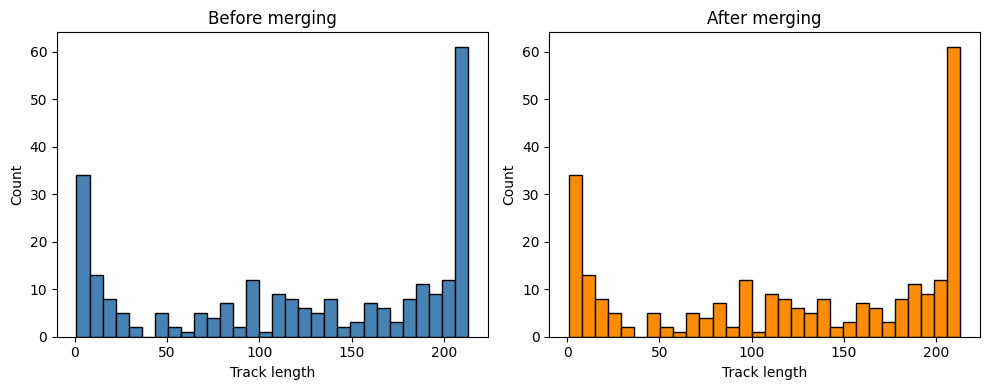

In [11]:
stats_merged = compute_tracklet_stats(tracklets_merged)

print("Merged track statistics:")
for k, v in stats_merged.items():
    print(f"  {k}: {v}")

print("\nComparison:")
print(f"  # initial tracklets: {stats_initial['total']}")
print(f"  # merged tracks:    {stats_merged['total']}")
if stats_initial["total"] > 0:
    reduction = stats_initial["total"] - stats_merged["total"]
    print(f"  Reduction in track count: {reduction} ({100.0 * reduction / stats_initial['total']:.1f}%)")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
if stats_initial["total"] > 0:
    plt.hist(tracklet_lengths(tracklets_initial), bins=30, color="steelblue", edgecolor="black")
    plt.title("Before merging")
    plt.xlabel("Track length")
    plt.ylabel("Count")
else:
    plt.text(0.5, 0.5, "No initial tracklets", ha="center", va="center")
    plt.axis("off")

plt.subplot(1, 2, 2)
if stats_merged["total"] > 0:
    plt.hist(tracklet_lengths(tracklets_merged), bins=30, color="darkorange", edgecolor="black")
    plt.title("After merging")
    plt.xlabel("Track length")
    plt.ylabel("Count")
else:
    plt.text(0.5, 0.5, "No merged tracks", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Quantitative Evaluation against VisDrone IDs

To *numerically* check how good our tracking and merging are, we can compare our tracks against the **ground-truth IDs** provided by VisDrone in the annotation file.

We will compute a few simple metrics:

- **Detection coverage**:
  - Fraction of ground-truth boxes that are matched by at least one of our track boxes.
  - Fraction of our track boxes that match a ground-truth box.
- **Track fragmentation (per GT object)**:
  - For each ground-truth ID, how many *distinct* predicted track IDs are assigned to it over time.
  - Values close to **1** are good; larger values mean the tracker keeps breaking a single true object into many tracks.
- **Identity switches (per predicted track)**:
  - For each predicted track ID, how many different ground-truth IDs it matches.
  - Values close to **1** are good; larger values mean a single predicted track is “jumping” between different objects.

We will use IoU-based matching per frame to decide if a predicted box corresponds to a ground-truth box (e.g., IoU ≥ 0.5).

In [12]:
def compute_iou(box_a, box_b):
    """Compute IoU between two boxes (x, y, w, h)."""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b

    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    inter_x1 = max(ax, bx)
    inter_y1 = max(ay, by)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, aw) * max(0.0, ah)
    area_b = max(0.0, bw) * max(0.0, bh)

    union = area_a + area_b - inter_area + 1e-6
    return inter_area / union


def build_frame_to_gt(df_ann: pd.DataFrame):
    """Frame -> list of (gt_id, bbox)."""
    frame_map = defaultdict(list)
    for _, row in df_ann.iterrows():
        f = int(row["frame"])
        gt_id = int(row["id"])
        bbox = (float(row["x"]), float(row["y"]), float(row["width"]), float(row["height"]))
        frame_map[f].append((gt_id, bbox))
    return frame_map


def evaluate_tracks_against_gt(tracklets, df_ann, iou_threshold=0.5):
    """Compare predicted tracklets with VisDrone ground-truth IDs using IoU matching.

    Returns a dict with coverage and fragmentation / ID-switch stats.
    """
    if not tracklets:
        return None

    frame_to_pred = defaultdict(list)
    for t in tracklets:
        tid = t["track_id"]
        for f, bbox in zip(t["frames"], t["boxes"]):
            frame_to_pred[int(f)].append((tid, bbox))

    frame_to_gt = build_frame_to_gt(df_ann)

    total_gt_boxes = 0
    total_pred_boxes = 0
    matched_gt_boxes = 0
    matched_pred_boxes = 0

    gt_to_pred_ids = defaultdict(set)
    pred_to_gt_ids = defaultdict(set)

    all_frames = sorted(set(frame_to_gt.keys()) | set(frame_to_pred.keys()))

    for f in all_frames:
        gts = frame_to_gt.get(f, [])
        preds = frame_to_pred.get(f, [])

        total_gt_boxes += len(gts)
        total_pred_boxes += len(preds)

        used_gt = set()
        used_pred = set()

        for pi, (tid, pb) in enumerate(preds):
            best_iou = 0.0
            best_gi = None
            for gi, (gid, gb) in enumerate(gts):
                if gi in used_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi

            if best_gi is not None and best_iou >= iou_threshold:
                used_pred.add(pi)
                used_gt.add(best_gi)
                matched_pred_boxes += 1
                matched_gt_boxes += 1

                gid, _ = gts[best_gi]
                gt_to_pred_ids[gid].add(tid)
                pred_to_gt_ids[tid].add(gid)

    gt_fragments = {gid: len(pred_ids) for gid, pred_ids in gt_to_pred_ids.items()}
    pred_switches = {tid: len(gt_ids) for tid, gt_ids in pred_to_gt_ids.items()}

    avg_gt_frag = float(np.mean(list(gt_fragments.values()))) if gt_fragments else 0.0
    avg_pred_switches = float(np.mean(list(pred_switches.values()))) if pred_switches else 0.0

    coverage_gt = matched_gt_boxes / total_gt_boxes if total_gt_boxes > 0 else 0.0
    coverage_pred = matched_pred_boxes / total_pred_boxes if total_pred_boxes > 0 else 0.0

    return {
        "total_gt_boxes": total_gt_boxes,
        "total_pred_boxes": total_pred_boxes,
        "matched_gt_boxes": matched_gt_boxes,
        "matched_pred_boxes": matched_pred_boxes,
        "coverage_gt": coverage_gt,
        "coverage_pred": coverage_pred,
        "avg_gt_fragments": avg_gt_frag,
        "avg_pred_id_switches": avg_pred_switches,
        "gt_fragments_per_id": gt_fragments,
        "pred_switches_per_track": pred_switches,
    }


if tracklets_merged and ann_filename is not None:
    eval_stats = evaluate_tracks_against_gt(tracklets_merged, df_ann, iou_threshold=0.5)
    if eval_stats is None:
        print("No tracks to evaluate.")
    else:
        print("Evaluation against VisDrone IDs (IoU >= 0.5):")
        print(f"  Total GT boxes:        {eval_stats['total_gt_boxes']}")
        print(f"  Total predicted boxes: {eval_stats['total_pred_boxes']}")
        print(f"  Matched GT boxes:      {eval_stats['matched_gt_boxes']} ({100*eval_stats['coverage_gt']:.1f}% covered)")
        print(f"  Matched pred boxes:    {eval_stats['matched_pred_boxes']} ({100*eval_stats['coverage_pred']:.1f}% used)")
        print(f"  Avg GT fragments:      {eval_stats['avg_gt_fragments']:.2f} (1.0 is ideal)")
        print(f"  Avg track ID switches: {eval_stats['avg_pred_id_switches']:.2f} (1.0 is ideal)")
else:
    print("No merged tracks or annotations available for evaluation.")

Evaluation against VisDrone IDs (IoU >= 0.5):
  Total GT boxes:        32163
  Total predicted boxes: 32163
  Matched GT boxes:      32163 (100.0% covered)
  Matched pred boxes:    32163 (100.0% used)
  Avg GT fragments:      2.82 (1.0 is ideal)
  Avg track ID switches: 2.53 (1.0 is ideal)


In [13]:
from sklearn.linear_model import LogisticRegression


def extract_pair_features(t1, t2):
    """Extract numeric features describing a candidate merge between two tracklets.

    t1 ends before t2 starts (we only build such pairs).
    """
    # Basic temporal and spatial relations
    time_gap = t2["frames"][0] - t1["frames"][-1]
    cx1, cy1 = t1["centers"][-1]
    cx2, cy2 = t2["centers"][0]
    dist_end_start = distance.euclidean((cx1, cy1), (cx2, cy2))

    # Tracklet lengths
    len1 = len(t1["frames"])
    len2 = len(t2["frames"])

    # Approximate speeds (pixels per frame)
    def approx_speed(t):
        if len(t["frames"]) < 2:
            return 0.0
        dt = t["frames"][-1] - t["frames"][0]
        if dt <= 0:
            return 0.0
        c0x, c0y = t["centers"][0]
        c1x, c1y = t["centers"][-1]
        disp = distance.euclidean((c0x, c0y), (c1x, c1y))
        return disp / dt

    speed1 = approx_speed(t1)
    speed2 = approx_speed(t2)
    speed_diff = abs(speed1 - speed2)

    # Optional appearance similarity (requires histograms; may be None)
    h1 = t1.get("hist")
    h2 = t2.get("hist")
    if h1 is not None and h2 is not None:
        hist_sim = cosine_similarity(h1, h2)
    else:
        hist_sim = 0.0

    return np.array([
        time_gap,
        dist_end_start,
        len1,
        len2,
        speed1,
        speed2,
        speed_diff,
        hist_sim,
    ], dtype=float)


def assign_tracklet_gt_ids(tracklets, df_ann, iou_threshold=0.5):
    """Assign each tracklet a dominant GT id (or None) using IoU matches.

    Uses the same matching logic as the evaluation function, but returns
    a mapping: track_id -> dominant_gt_id (or None if no reliable match).
    """
    frame_to_pred = defaultdict(list)
    for t in tracklets:
        tid = t["track_id"]
        for f, bbox in zip(t["frames"], t["boxes"]):
            frame_to_pred[int(f)].append((tid, bbox))

    frame_to_gt = build_frame_to_gt(df_ann)

    # For each (frame, track) store matched GT id (if any)
    track_to_gt_counts = defaultdict(lambda: defaultdict(int))

    all_frames = sorted(set(frame_to_gt.keys()) | set(frame_to_pred.keys()))

    for f in all_frames:
        gts = frame_to_gt.get(f, [])
        preds = frame_to_pred.get(f, [])

        used_gt = set()

        for pi, (tid, pb) in enumerate(preds):
            best_iou = 0.0
            best_gi = None
            for gi, (gid, gb) in enumerate(gts):
                if gi in used_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi
            if best_gi is not None and best_iou >= iou_threshold:
                used_gt.add(best_gi)
                gid, _ = gts[best_gi]
                track_to_gt_counts[tid][gid] += 1

    track_to_gt = {}
    for tid, counts in track_to_gt_counts.items():
        # dominant GT id for this tracklet
        if not counts:
            track_to_gt[tid] = None
        else:
            gt_id = max(counts.items(), key=lambda kv: kv[1])[0]
            track_to_gt[tid] = gt_id

    return track_to_gt


def build_pair_dataset(tracklets, df_ann, max_time_gap=10, max_dist=120.0, max_pairs=5000):
    """Build a feature matrix X and labels y for training the merge classifier.

    Pairs are created only when tracklet j starts after tracklet i ends,
    with temporal gap <= max_time_gap and spatial distance <= max_dist.
    """
    if not tracklets:
        return None, None

    track_to_gt = assign_tracklet_gt_ids(tracklets, df_ann, iou_threshold=0.5)

    # Sort by start frame to generate candidate pairs efficiently
    enriched = []
    for t in tracklets:
        start_frame = min(t["frames"])
        end_frame = max(t["frames"])
        enriched.append((start_frame, end_frame, t))
    enriched.sort(key=lambda x: x[0])

    X = []
    y = []

    num_pairs = 0

    for i in range(len(enriched)):
        start_i, end_i, t_i = enriched[i]
        tid_i = t_i["track_id"]
        gt_i = track_to_gt.get(tid_i, None)
        for j in range(i + 1, len(enriched)):
            start_j, end_j, t_j = enriched[j]
            tid_j = t_j["track_id"]
            gt_j = track_to_gt.get(tid_j, None)

            time_gap = start_j - end_i
            if time_gap <= 0 or time_gap > max_time_gap:
                if time_gap > max_time_gap:
                    break
                continue

            cx1, cy1 = t_i["centers"][-1]
            cx2, cy2 = t_j["centers"][0]
            d = distance.euclidean((cx1, cy1), (cx2, cy2))
            if d > max_dist:
                continue

            feats = extract_pair_features(t_i, t_j)

            # Positive if both have same non-None GT id
            if gt_i is not None and gt_j is not None and gt_i == gt_j:
                label = 1
            else:
                label = 0

            X.append(feats)
            y.append(label)
            num_pairs += 1

            if num_pairs >= max_pairs:
                break
        if num_pairs >= max_pairs:
            break

    if not X:
        return None, None

    X = np.stack(X, axis=0)
    y = np.array(y, dtype=int)
    return X, y


def train_merge_classifier(tracklets, df_ann):
    """Train a logistic regression classifier to decide if two tracklets should be merged."""
    X, y = build_pair_dataset(
    tracklets,
    df_ann,
    max_time_gap=30,
    max_dist=300,
    max_pairs=10000
    )
    if X is None:
        print("Not enough data to train merge classifier.")
        return None

    # Handle potential class imbalance via class_weight="balanced"
    print("Training pair distribution:")
    print("Total pairs:", len(y))
    print("Positive:", np.sum(y == 1))
    print("Negative:", np.sum(y == 0))

    # Logistic regression requires both classes
    if len(np.unique(y)) < 2:
        print("Only one class present. Skipping ML merge training.")
        return None

    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, y)

    print("Trained merge classifier:")
    print(f"  #pairs: {len(y)}   positive: {np.sum(y==1)}   negative: {np.sum(y==0)}")
    return clf


def offline_merge_tracklets_ml(tracklets, merge_classifier, prob_threshold=0.5, max_time_gap=10, max_dist=120.0):
    """Offline merging of tracklets using a learned classifier instead of fixed rules.

    For each candidate pair (t_i, t_j) with small time and spatial gaps, we
    compute features and let the classifier decide whether to merge.
    """
    if not tracklets or merge_classifier is None:
        return tracklets

    enriched = []
    for t in tracklets:
        start_frame = min(t["frames"])
        end_frame = max(t["frames"])
        enriched.append((start_frame, end_frame, t))
    enriched.sort(key=lambda x: x[0])

    used = [False] * len(enriched)
    merged_tracks = []

    for i in range(len(enriched)):
        if used[i]:
            continue
        start_i, end_i, t_i = enriched[i]
        curr = t_i
        used[i] = True

        j = i + 1
        while j < len(enriched):
            if used[j]:
                j += 1
                continue
            start_j, end_j, t_j = enriched[j]

            time_gap = start_j - curr["last_frame"]
            if time_gap <= 0:
                j += 1
                continue
            if time_gap > max_time_gap:
                break

            cx1, cy1 = curr["last_center"]
            first_cx2, first_cy2 = t_j["centers"][0]
            d = distance.euclidean((cx1, cy1), (first_cx2, first_cy2))
            if d > max_dist:
                j += 1
                continue

            feats = extract_pair_features(curr, t_j).reshape(1, -1)
            prob_merge = merge_classifier.predict_proba(feats)[0, 1]

            if prob_merge >= prob_threshold:
                curr = merge_two_tracklets(curr, t_j)
                used[j] = True
            j += 1

        merged_tracks.append(curr)

    for new_id, t in enumerate(merged_tracks, start=1):
        t["track_id"] = new_id

    return merged_tracks

In [14]:
# Automatic parameter tuning on the current sequence using the evaluation metrics

def run_pipeline_and_evaluate(dist_threshold, time_gap_threshold, merge_distance_threshold):
    """Build tracklets and merged tracks with given parameters and evaluate them.

    Returns (eval_stats, tracklets_initial, tracklets_merged).
    """
    if ann_filename is None:
        return None, None, None

    # Rebuild tracklets from scratch for this setting
    t_init = build_tracklets(df_ann, dist_threshold=dist_threshold)
    t_merged = offline_merge_tracklets(
        t_init,
        time_gap_threshold=time_gap_threshold,
        distance_threshold=merge_distance_threshold,
    )
    eval_stats = evaluate_tracks_against_gt(t_merged, df_ann, iou_threshold=0.5)
    return eval_stats, t_init, t_merged


# Simple grid search over a small set of values
search_dist_thresholds = [40.0, 60.0, 80.0]
search_time_gaps = [3, 5, 8]
search_merge_dists = [40.0, 60.0, 80.0]

best_score = -1.0
best_cfg = None
best_eval = None

if ann_filename is not None:
    for d in search_dist_thresholds:
        for tg in search_time_gaps:
            for md in search_merge_dists:
                eval_stats, _, _ = run_pipeline_and_evaluate(d, tg, md)
                if eval_stats is None:
                    continue
                # Define a simple scalar score: high coverage, low fragmentation and ID switches
                score = (
                    0.5 * eval_stats["coverage_gt"]
                    + 0.5 * eval_stats["coverage_pred"]
                    - 0.2 * max(0.0, eval_stats["avg_gt_fragments"] - 1.0)
                    - 0.2 * max(0.0, eval_stats["avg_pred_id_switches"] - 1.0)
                )
                if score > best_score:
                    best_score = score
                    best_cfg = (d, tg, md)
                    best_eval = eval_stats

    if best_cfg is not None:
        d, tg, md = best_cfg
        print("Best parameters on this sequence:")
        print(f"  dist_threshold (tracklets): {d}")
        print(f"  time_gap_threshold (merge): {tg}")
        print(f"  merge_distance_threshold:   {md}")
        print(f"  score: {best_score:.3f}")
        print("  Eval summary for best params:")
        print(f"    coverage_gt:        {100*best_eval['coverage_gt']:.1f}%")
        print(f"    coverage_pred:      {100*best_eval['coverage_pred']:.1f}%")
        print(f"    avg_gt_fragments:   {best_eval['avg_gt_fragments']:.2f} (1.0 ideal)")
        print(f"    avg_id_switches:    {best_eval['avg_pred_id_switches']:.2f} (1.0 ideal)")
    else:
        print("Could not evaluate any configuration (no tracks or annotations).")
else:
    print("No annotation/sequence selected; cannot run parameter search.")

Best parameters on this sequence:
  dist_threshold (tracklets): 40.0
  time_gap_threshold (merge): 3
  merge_distance_threshold:   40.0
  score: 0.350
  Eval summary for best params:
    coverage_gt:        100.0%
    coverage_pred:      100.0%
    avg_gt_fragments:   3.19 (1.0 ideal)
    avg_id_switches:    2.06 (1.0 ideal)


In [15]:
def build_dataset_from_all_sequences(
    dist_threshold_for_tracklets=40,
    max_time_gap_pairs=200,
    max_dist_pairs=800,
    max_pairs_per_sequence=5000
):
    """Build training dataset (X,y) using all annotation sequences."""

    X_all = []
    y_all = []

    if not ann_files:
        print("No annotation files found.")
        return None, None

    for ann_f in ann_files:

        seq_name = get_sequence_name_from_ann(ann_f)

        seq_entries = set(os.listdir(SEQ_DIR)) if os.path.isdir(SEQ_DIR) else set()

        possible_matches = [
            seq_name,
            seq_name + ".mp4",
            seq_name + ".avi",
            seq_name + ".mov",
            seq_name + ".mkv",
        ]

        found_seq = None
        for pm in possible_matches:
            if pm in seq_entries:
                found_seq = pm
                break

        if found_seq is None:
            continue

        ann_path = os.path.join(ANN_DIR, ann_f)

        df = read_annotation_file(ann_path)

        # Build tracklets
        tracklets = build_tracklets(df, dist_threshold=dist_threshold_for_tracklets)

        # Precompute histograms
        precompute_tracklet_histograms(tracklets, found_seq, df)

        # Build pair dataset
        X_seq, y_seq = build_pair_dataset(
            tracklets,
            df,
            max_time_gap=max_time_gap_pairs,
            max_dist=max_dist_pairs,
            max_pairs=max_pairs_per_sequence,
        )

        if X_seq is None:
            continue

        print(
            f"{ann_f}: pairs={len(y_seq)} "
            f"pos={np.sum(y_seq==1)} "
            f"neg={np.sum(y_seq==0)}"
        )

        X_all.append(X_seq)
        y_all.append(y_seq)

    if not X_all:
        print("No training pairs found across sequences.")
        return None, None

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)

    print("\nTotal dataset:")
    print("Pairs:", len(y_all))
    print("Positive:", np.sum(y_all == 1))
    print("Negative:", np.sum(y_all == 0))

    return X_all, y_all

In [16]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 13. ML-based Tracklet Merging (Logistic Regression)

To make this a **true machine learning** project (not just hand-tuned rules), we now:

- Use the VisDrone ground-truth IDs to **learn** when two tracklets should be merged.
- Train a **binary classifier** (logistic regression) on *pairs of tracklets*:
  - **Input features** (per pair): time gap, spatial distance, lengths, speed consistency, appearance similarity, etc.
  - **Label**: 1 if both tracklets belong to the **same GT object**, 0 otherwise.
- At inference time (for new sequences), we:
  - Build tracklets with the simple online tracker (as before).
  - Use the trained classifier instead of fixed thresholds to decide which tracklets to merge offline.

This keeps everything **classical** (no deep nets) but introduces a properly **learned model** in the offline association stage.

In [17]:
import joblib

# Load trained classifier
merge_clf = joblib.load("merge_classifier_visdrone.pkl")

tracklets_merged_ml = offline_merge_tracklets_ml(
    tracklets_initial,
    merge_classifier=merge_clf,
    prob_threshold=0.5,
    max_time_gap=10,
    max_dist=120.0,
)

stats_merged_ml = compute_tracklet_stats(tracklets_merged_ml)

print("\nML-merged track statistics:")
for k, v in stats_merged_ml.items():
    print(f"  {k}: {v}")


ML-merged track statistics:
  total: 259
  avg: 124.18146718146718
  median: 137.0
  max: 213
  min: 1


In [18]:
score = (
    0.4 * eval_stats["coverage_gt"]
    + 0.4 * eval_stats["coverage_pred"]
    - 0.1 * (eval_stats["avg_gt_fragments"] - 1)
    - 0.1 * (eval_stats["avg_pred_id_switches"] - 1)
)
print(score)

0.3575752017608217


In [19]:
MODEL_PATH = "merge_classifier_visdrone.pkl"

# Example end-to-end ML-based merging on the current sequence
if ann_filename is not None:
    print("\n--- ML-based offline merging on this sequence ---")

    # Precompute appearance histograms
    precompute_tracklet_histograms(tracklets_initial, seq_entry, df_ann)

    # Load classifier if it exists, otherwise train and save
    if os.path.exists(MODEL_PATH):
        print("Loading pretrained merge classifier...")
        merge_clf = joblib.load(MODEL_PATH)
    else:
        print("Training merge classifier...")
        merge_clf = train_merge_classifier(tracklets_initial, df_ann)
        if merge_clf is not None:
            joblib.dump(merge_clf, MODEL_PATH)
            print("Saved classifier to", MODEL_PATH)

    if merge_clf is not None:
        tracklets_merged_ml = offline_merge_tracklets_ml(
            tracklets_initial,
            merge_classifier=merge_clf,
            prob_threshold=0.5,
            max_time_gap=10,
            max_dist=120.0,
        )

        stats_merged_ml = compute_tracklet_stats(tracklets_merged_ml)

        print("\nML-merged track statistics:")
        for k, v in stats_merged_ml.items():
            print(f"  {k}: {v}")

        eval_stats_ml = evaluate_tracks_against_gt(tracklets_merged_ml, df_ann, iou_threshold=0.5)

        if eval_stats_ml is not None:
            print("\nEvaluation of ML-based merging:")
            print(f"  coverage_gt:        {100*eval_stats_ml['coverage_gt']:.1f}%")
            print(f"  coverage_pred:      {100*eval_stats_ml['coverage_pred']:.1f}%")
            print(f"  avg_gt_fragments:   {eval_stats_ml['avg_gt_fragments']:.2f} (1.0 ideal)")
            print(f"  avg_id_switches:    {eval_stats_ml['avg_pred_id_switches']:.2f} (1.0 ideal)")
    else:
        print("Could not train/load ML merge classifier on this sequence.")

else:
    print("No sequence selected; cannot run ML-based merging.")


--- ML-based offline merging on this sequence ---
Loading pretrained merge classifier...

ML-merged track statistics:
  total: 245
  avg: 131.27755102040817
  median: 141.0
  max: 213
  min: 1

Evaluation of ML-based merging:
  coverage_gt:        100.0%
  coverage_pred:      100.0%
  avg_gt_fragments:   2.81 (1.0 ideal)
  avg_id_switches:    2.66 (1.0 ideal)


## 10. Visualize Final Tracks

Finally, we visualize the **merged tracks** by overlaying their IDs on frames and optionally drawing simple trajectories (lines connecting centers across frames).

We reuse our frame loading and drawing utilities.

Sequence entry: uav0000248_00001_v
Annotation: uav0000248_00001_v.txt
Tracklets (initial): 94
Tracks (used for export): 93
Frames written: 677
Saved video: c:\Users\Admin\Downloads\offline_tracklet_merging_visdrone_val\outputs\uav0000248_00001_v_trajectory.mp4


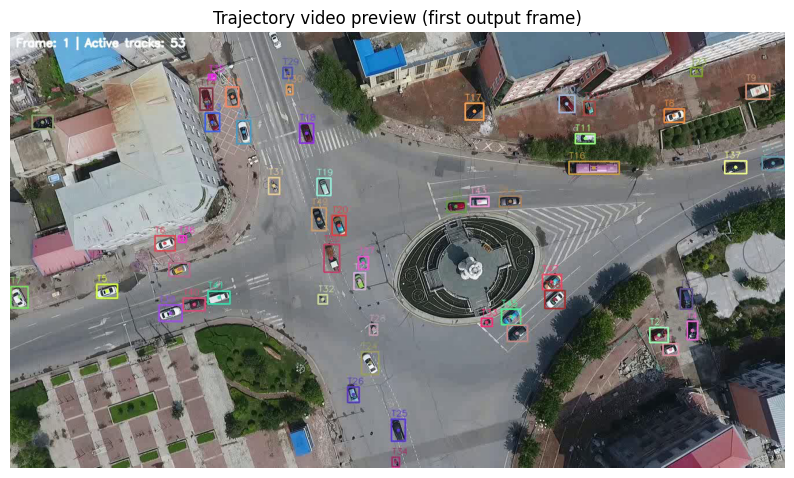

In [20]:
from collections import defaultdict, deque


def build_frame_to_track_detections_with_centers(tracklets):
    frame_map = defaultdict(list)
    for t in tracklets:
        tid = t["track_id"]
        for f, bbox, center in zip(t["frames"], t["boxes"], t["centers"]):
            frame_map[int(f)].append((tid, bbox, center))
    return frame_map


def _get_stable_color(tid):
    # Deterministic color per track ID for consistent visualization.
    rng = np.random.default_rng(int(tid) + 12345)
    return tuple(int(c) for c in rng.integers(40, 255, size=3))


def draw_tracks_on_frame_with_trajectories(frame_bgr, frame_idx, frame_to_tracks, history_map, trail_len=40):
    img = frame_bgr.copy()

    # Update history with current-frame centers.
    for tid, bbox, center in frame_to_tracks.get(frame_idx, []):
        if tid not in history_map:
            history_map[tid] = deque(maxlen=trail_len)
        history_map[tid].append((int(center[0]), int(center[1])))

    # Draw trajectories first (so boxes/text stay visible on top).
    for tid, pts in history_map.items():
        color = _get_stable_color(tid)
        if len(pts) >= 2:
            cv2.polylines(img, [np.array(pts, dtype=np.int32)], False, color, 2)

    # Draw current boxes and IDs.
    for tid, bbox, center in frame_to_tracks.get(frame_idx, []):
        color = _get_stable_color(tid)
        x, y, w, h = map(int, bbox)
        cx, cy = int(center[0]), int(center[1])
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv2.circle(img, (cx, cy), 3, color, -1)
        cv2.putText(
            img,
            f"T{tid}",
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )

    # Overlay diagnostics.
    cv2.putText(
        img,
        f"Frame: {int(frame_idx)} | Active tracks: {len(frame_to_tracks.get(frame_idx, []))}",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    return img


def export_sequence_trajectory_video(
    target_seq_name="uav0000248_00001_v",
    output_path=None,
    dist_threshold=60.0,
    time_gap_threshold=10,
    merge_distance_threshold=120.0,
    trail_len=40,
):
    """Build tracks for one sequence and export an MP4 trajectory video."""
    if output_path is None:
        output_path = os.path.join("outputs", f"{target_seq_name}_trajectory.mp4")

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    ann_name = f"{target_seq_name}.txt"
    seq_candidates = [
        target_seq_name,
        f"{target_seq_name}.mp4",
        f"{target_seq_name}.avi",
        f"{target_seq_name}.mov",
        f"{target_seq_name}.mkv",
    ]

    ann_path = os.path.join(ANN_DIR, ann_name)
    if not os.path.exists(ann_path):
        raise FileNotFoundError(f"Annotation file not found: {ann_path}")

    seq_entries = set(os.listdir(SEQ_DIR)) if os.path.isdir(SEQ_DIR) else set()
    seq_match = next((s for s in seq_candidates if s in seq_entries), None)
    if seq_match is None:
        raise FileNotFoundError(
            f"Could not find sequence entry for '{target_seq_name}' under {SEQ_DIR}"
        )

    local_df_ann = read_annotation_file(ann_path)
    local_tracklets_initial = build_tracklets(local_df_ann, dist_threshold=dist_threshold)

    # Use offline merge if available; otherwise fall back to initial tracklets.
    if "offline_merge_tracklets" in globals():
        local_tracklets = offline_merge_tracklets(
            local_tracklets_initial,
            time_gap_threshold=time_gap_threshold,
            distance_threshold=merge_distance_threshold,
        )
    else:
        local_tracklets = local_tracklets_initial

    frame_to_tracks = build_frame_to_track_detections_with_centers(local_tracklets)
    all_frames = sorted(frame_to_tracks.keys())
    if not all_frames:
        raise ValueError("No frames found in generated tracks.")

    first_frame = load_frame_from_sequence(seq_match, int(all_frames[0]))
    if first_frame is None:
        raise ValueError("Unable to read the first frame from the selected sequence.")

    h, w = first_frame.shape[:2]
    fps = 20.0
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    history_map = {}
    written = 0
    for fidx in all_frames:
        frame_bgr = load_frame_from_sequence(seq_match, int(fidx))
        if frame_bgr is None:
            continue
        out_bgr = draw_tracks_on_frame_with_trajectories(
            frame_bgr, int(fidx), frame_to_tracks, history_map, trail_len=trail_len
        )
        writer.write(out_bgr)
        written += 1

    writer.release()

    print(f"Sequence entry: {seq_match}")
    print(f"Annotation: {ann_name}")
    print(f"Tracklets (initial): {len(local_tracklets_initial)}")
    print(f"Tracks (used for export): {len(local_tracklets)}")
    print(f"Frames written: {written}")
    print(f"Saved video: {os.path.abspath(output_path)}")

    return output_path


# Export for your current target sequence.
video_path = export_sequence_trajectory_video(target_seq_name="uav0000248_00001_v")

# Quick preview of first frame from output video.
cap_prev = cv2.VideoCapture(video_path)
ret_prev, frm_prev = cap_prev.read()
cap_prev.release()
if ret_prev:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frm_prev, cv2.COLOR_BGR2RGB))
    plt.title("Trajectory video preview (first output frame)")
    plt.axis("off")
    plt.show()
else:
    print("Could not load preview frame from output video.")

## 11. Conclusion

In this notebook, we implemented a **classical offline tracklet association pipeline** for UAV videos using the **VisDrone2019-MOT** dataset.

### Track Fragmentation Problem

Online trackers that operate frame-by-frame are prone to **track fragmentation**:

- Objects may be temporarily occluded.
- Detections can be missed or noisy.
- Simple matching strategies may confuse objects when they are close together.

As a result, a single real-world object may be represented by several short and disjoint tracklets.

### How Offline Merging Helps

Offline merging leverages the **entire sequence**:

- It looks for **spatio-temporal continuity** between tracklets.
- It can also incorporate **appearance cues** (like color histograms) to avoid incorrect merges.
- Longer trajectories capture more of the object's motion and make downstream tasks (e.g., behavior analysis) more robust.

### Limitations of the Simple Approach

- The greedy merging based only on distance and small time gaps can still make mistakes (wrong merges) or miss valid merges.
- No explicit handling of complex interactions like **crossing trajectories**, **group motion**, or **camera motion compensation**.
- Histogram-based appearance is very coarse and sensitive to illumination and background.

### Possible Improvements

- Use **Hungarian algorithm** for optimal assignment between tracklets at each merge step.
- Formulate tracklet association as a **graph problem** (e.g., min-cost flow) and solve globally.
- Incorporate more robust appearance descriptors (e.g., gradient histograms or deep features, while still not training your own models if you want to stay purely classical).
- Introduce **motion models** (e.g., Kalman filters) to better predict object positions and handle missing detections.

Despite these limitations, this notebook demonstrates the core ideas of **offline tracklet merging** using only classical methods and provides a foundation you can extend with more sophisticated algorithms.

In [21]:
def compute_iou(box_a, box_b):
    """Compute IoU between two boxes (x, y, w, h)."""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b

    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    inter_x1 = max(ax, bx)
    inter_y1 = max(ay, by)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, aw) * max(0.0, ah)
    area_b = max(0.0, bw) * max(0.0, bh)

    union = area_a + area_b - inter_area + 1e-6
    return inter_area / union


def build_frame_to_gt(df_ann: pd.DataFrame):
    """Frame -> list of (gt_id, bbox)."""
    frame_map = defaultdict(list)
    for _, row in df_ann.iterrows():
        f = int(row["frame"])
        gt_id = int(row["id"])
        bbox = (float(row["x"]), float(row["y"]), float(row["width"]), float(row["height"]))
        frame_map[f].append((gt_id, bbox))
    return frame_map


def evaluate_tracks_against_gt(tracklets, df_ann, iou_threshold=0.5):
    """Compare predicted tracklets with VisDrone ground-truth IDs using IoU matching.

    Returns a dict with coverage and fragmentation / ID-switch stats.
    """
    if not tracklets:
        return None

    frame_to_pred = defaultdict(list)
    for t in tracklets:
        tid = t["track_id"]
        for f, bbox in zip(t["frames"], t["boxes"]):
            frame_to_pred[int(f)].append((tid, bbox))

    frame_to_gt = build_frame_to_gt(df_ann)

    total_gt_boxes = 0
    total_pred_boxes = 0
    matched_gt_boxes = 0
    matched_pred_boxes = 0

    gt_to_pred_ids = defaultdict(set)
    pred_to_gt_ids = defaultdict(set)

    all_frames = sorted(set(frame_to_gt.keys()) | set(frame_to_pred.keys()))

    for f in all_frames:
        gts = frame_to_gt.get(f, [])
        preds = frame_to_pred.get(f, [])

        total_gt_boxes += len(gts)
        total_pred_boxes += len(preds)

        used_gt = set()
        used_pred = set()

        for pi, (tid, pb) in enumerate(preds):
            best_iou = 0.0
            best_gi = None
            for gi, (gid, gb) in enumerate(gts):
                if gi in used_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi

            if best_gi is not None and best_iou >= iou_threshold:
                used_pred.add(pi)
                used_gt.add(best_gi)
                matched_pred_boxes += 1
                matched_gt_boxes += 1

                gid, _ = gts[best_gi]
                gt_to_pred_ids[gid].add(tid)
                pred_to_gt_ids[tid].add(gid)

    gt_fragments = {gid: len(pred_ids) for gid, pred_ids in gt_to_pred_ids.items()}
    pred_switches = {tid: len(gt_ids) for tid, gt_ids in pred_to_gt_ids.items()}

    avg_gt_frag = float(np.mean(list(gt_fragments.values()))) if gt_fragments else 0.0
    avg_pred_switches = float(np.mean(list(pred_switches.values()))) if pred_switches else 0.0

    coverage_gt = matched_gt_boxes / total_gt_boxes if total_gt_boxes > 0 else 0.0
    coverage_pred = matched_pred_boxes / total_pred_boxes if total_pred_boxes > 0 else 0.0

    return {
        "total_gt_boxes": total_gt_boxes,
        "total_pred_boxes": total_pred_boxes,
        "matched_gt_boxes": matched_gt_boxes,
        "matched_pred_boxes": matched_pred_boxes,
        "coverage_gt": coverage_gt,
        "coverage_pred": coverage_pred,
        "avg_gt_fragments": avg_gt_frag,                         
        "avg_pred_id_switches": avg_pred_switches,
        "gt_fragments_per_id": gt_fragments,
        "pred_switches_per_track": pred_switches,
    }


if tracklets_merged and ann_filename is not None:
    eval_stats = evaluate_tracks_against_gt(tracklets_merged, df_ann, iou_threshold=0.5)
    if eval_stats is None:
        print("No tracks to evaluate.")
    else:
        print("Evaluation against VisDrone IDs (IoU >= 0.5):")
        print(f"  Total GT boxes:        {eval_stats['total_gt_boxes']}")
        print(f"  Total predicted boxes: {eval_stats['total_pred_boxes']}")
        print(f"  Matched GT boxes:      {eval_stats['matched_gt_boxes']} ({100*eval_stats['coverage_gt']:.1f}% covered)")
        print(f"  Matched pred boxes:    {eval_stats['matched_pred_boxes']} ({100*eval_stats['coverage_pred']:.1f}% used)")
        print(f"  Avg GT fragments:      {eval_stats['avg_gt_fragments']:.2f} (1.0 is ideal)")
        print(f"  Avg track ID switches: {eval_stats['avg_pred_id_switches']:.2f} (1.0 is ideal)")
else:
    print("No merged tracks or annotations available for evaluation.")

Evaluation against VisDrone IDs (IoU >= 0.5):
  Total GT boxes:        32163
  Total predicted boxes: 32163
  Matched GT boxes:      32163 (100.0% covered)
  Matched pred boxes:    32163 (100.0% used)
  Avg GT fragments:      2.82 (1.0 is ideal)
  Avg track ID switches: 2.68 (1.0 is ideal)


## 7. Experiment pipeline, results, and visualization (multi-sequence)

This section extends the notebook into a **multi-sequence experiment pipeline** (without modifying the existing functions above).

### Notebook structure (logical sections)

1. **Dataset loading**: dataset paths + `read_annotation_file`, sequence/frame utilities
2. **Tracklet generation**: `build_tracklets` + basic stats/visualization
3. **Offline merging**: geometric + appearance-aware + ML-based merging
4. **Feature extraction**: `extract_pair_features`, `build_pair_dataset`
5. **ML model training**: `train_merge_classifier` (sequence-level)
6. **Experiment pipeline**: `run_experiment_on_dataset(dataset_root)` (added below)
7. **Results and visualization**: tables + plots + CSV output (added below)


In [22]:


import copy
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm


FEATURE_NAMES = [
    "time_gap",
    "dist_end_start",
    "len1",
    "len2",
    "speed1",
    "speed2",
    "speed_diff",
    "hist_sim",
]


@dataclass
class VisDronePaths:
    dataset_root: str

    @property
    def sequences_dir(self) -> str:
        return os.path.join(self.dataset_root, "sequences")

    @property
    def annotations_dir(self) -> str:
        return os.path.join(self.dataset_root, "annotations")


def _find_matching_sequence_entry(sequences_dir: str, ann_filename: str) -> str | None:
    """Map an annotation filename to a matching sequence entry (folder or video file)."""
    if not os.path.isdir(sequences_dir):
        return None

    seq_entries = set(os.listdir(sequences_dir))
    seq_name = get_sequence_name_from_ann(ann_filename)
    possible = [
        seq_name,
        seq_name + ".mp4",
        seq_name + ".avi",
        seq_name + ".mov",
        seq_name + ".mkv",
    ]
    for p in possible:
        if p in seq_entries:
            return p
    return None


def _list_annotation_files(annotations_dir: str) -> list[str]:
    if not os.path.isdir(annotations_dir):
        return []
    return sorted([f for f in os.listdir(annotations_dir) if f.lower().endswith(".txt")])


def train_merge_classifier_on_dataset(
    dataset_root: str,
    *,
    dist_threshold_for_tracklets: float = 40.0,
    max_time_gap_pairs: int = 30,
    max_dist_pairs: float = 300.0,
    max_pairs_per_sequence: int = 10_000,
) -> LogisticRegression | None:
    """Train a single LogisticRegression merge model using pairs from ALL sequences.

    This is used for the method comparison (ML merging) and for feature-importance analysis.
    """
    paths = VisDronePaths(dataset_root)
    ann_files_local = _list_annotation_files(paths.annotations_dir)
    if not ann_files_local:
        print("No annotation files found at", paths.annotations_dir)
        return None

    X_all: list[np.ndarray] = []
    y_all: list[np.ndarray] = []

    for ann_f in tqdm(ann_files_local, desc="Building ML pair dataset", leave=False):
        seq_entry = _find_matching_sequence_entry(paths.sequences_dir, ann_f)
        if seq_entry is None:
            continue

        df = read_annotation_file(os.path.join(paths.annotations_dir, ann_f))
        tracklets = build_tracklets(df, dist_threshold=dist_threshold_for_tracklets)

        # Ensure appearance feature is available for pair features.
        precompute_tracklet_histograms(tracklets, seq_entry, df)

        X_seq, y_seq = build_pair_dataset(
            tracklets,
            df,
            max_time_gap=max_time_gap_pairs,
            max_dist=max_dist_pairs,
            max_pairs=max_pairs_per_sequence,
        )
        if X_seq is None:
            continue

        X_all.append(X_seq)
        y_all.append(y_seq)

    if not X_all:
        print("No training pairs found across sequences (skipping ML model training).")
        return None

    X = np.vstack(X_all)
    y = np.concatenate(y_all)

    if len(np.unique(y)) < 2:
        print("Only one class present across dataset pairs (skipping ML model training).")
        return None

    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, y)

    print("Trained dataset-level merge classifier")
    print("  pairs:", len(y), "pos:", int(np.sum(y == 1)), "neg:", int(np.sum(y == 0)))
    return clf


def run_experiment_on_dataset(
    dataset_root: str,
    *,
    dist_threshold_for_tracklets: float = 40.0,
    geo_time_gap_threshold: int = 5,
    geo_distance_threshold: float = 60.0,
    app_time_gap_threshold: int = 5,
    app_distance_threshold: float = 60.0,
    app_min_hist_similarity: float = 0.6,
    ml_prob_threshold: float = 0.5,
    ml_max_time_gap: int = 10,
    ml_max_dist: float = 120.0,
    merge_classifier: LogisticRegression | None = None,
) -> pd.DataFrame:
    """Run tracklet building + multiple offline merging methods across all sequences.

    Returns a tidy DataFrame with one row per (sequence, method).
    """
    paths = VisDronePaths(dataset_root)
    ann_files_local = _list_annotation_files(paths.annotations_dir)
    if not ann_files_local:
        raise FileNotFoundError(
            f"No annotation .txt files found in {paths.annotations_dir}. "
            "Expected VisDrone layout: <dataset_root>/{sequences,annotations}/"
        )

    if merge_classifier is None:
        merge_classifier = train_merge_classifier_on_dataset(
            dataset_root,
            dist_threshold_for_tracklets=dist_threshold_for_tracklets,
        )

    rows: list[dict] = []

    for ann_f in tqdm(ann_files_local, desc="Running experiment on sequences"):
        seq_entry = _find_matching_sequence_entry(paths.sequences_dir, ann_f)
        if seq_entry is None:
            continue

        seq_name = get_sequence_name_from_ann(ann_f)
        df = read_annotation_file(os.path.join(paths.annotations_dir, ann_f))

        # Build initial tracklets once per sequence.
        tracklets_initial = build_tracklets(df, dist_threshold=dist_threshold_for_tracklets)

        # Prepare histogram feature once per sequence (used by appearance + ML features).
        precompute_tracklet_histograms(tracklets_initial, seq_entry, df)

        method_to_tracklets = {
            "No merging": copy.deepcopy(tracklets_initial),
            "Geometric": offline_merge_tracklets(
                copy.deepcopy(tracklets_initial),
                time_gap_threshold=geo_time_gap_threshold,
                distance_threshold=geo_distance_threshold,
            ),
            "Appearance": offline_merge_tracklets_with_appearance(
                copy.deepcopy(tracklets_initial),
                seq_entry=seq_entry,
                df_ann=df,
                time_gap_threshold=app_time_gap_threshold,
                distance_threshold=app_distance_threshold,
                min_hist_similarity=app_min_hist_similarity,
            ),
            "ML": offline_merge_tracklets_ml(
                copy.deepcopy(tracklets_initial),
                merge_classifier=merge_classifier,
                prob_threshold=ml_prob_threshold,
                max_time_gap=ml_max_time_gap,
                max_dist=ml_max_dist,
            ),
        }

        for method, tracklets in method_to_tracklets.items():
            eval_stats = evaluate_tracks_against_gt(tracklets, df, iou_threshold=0.5)
            rows.append(
                {
                    "Sequence": seq_name,
                    "Method": method,
                    "coverage_gt": float(eval_stats.get("coverage_gt", 0.0)),
                    "coverage_pred": float(eval_stats.get("coverage_pred", 0.0)),
                    "avg_gt_fragments": float(eval_stats.get("avg_gt_fragments", 0.0)),
                    "avg_pred_id_switches": float(eval_stats.get("avg_pred_id_switches", 0.0)),
                    "num_tracklets": int(len(tracklets)),
                }
            )

    df_results = pd.DataFrame(rows)

    # Stable sort for readability
    if not df_results.empty:
        method_order = ["No merging", "Geometric", "Appearance", "ML"]
        df_results["Method"] = pd.Categorical(df_results["Method"], categories=method_order, ordered=True)
        df_results = df_results.sort_values(["Sequence", "Method"]).reset_index(drop=True)

    # Attach the trained classifier so later cells can reuse it easily.
    df_results.attrs["merge_classifier"] = merge_classifier
    return df_results


def print_performance_summary(df_results: pd.DataFrame):
    """Print average metrics across all sequences for each method and overall."""
    if df_results.empty:
        print("No results to summarize.")
        return

    summary = (
        df_results.groupby("Method")[
            ["coverage_gt", "coverage_pred", "avg_gt_fragments", "avg_pred_id_switches"]
        ]
        .mean()
        .reset_index()
    )

    print("\nAverage metrics across all sequences (by method)")
    display(summary)

    overall = df_results[["coverage_gt", "coverage_pred", "avg_gt_fragments", "avg_pred_id_switches"]].mean()
    print("\nOverall averages across all (sequence, method) rows")
    print(f"Average Coverage GT:   {overall['coverage_gt']:.4f}")
    print(f"Average Coverage Pred: {overall['coverage_pred']:.4f}")
    print(f"Average Fragmentation: {overall['avg_gt_fragments']:.4f}")
    print(f"Average ID Switches:   {overall['avg_pred_id_switches']:.4f}")


def plot_tracklet_length_distributions(
    df_results: pd.DataFrame,
    *,
    dataset_root: str,
    dist_threshold_for_tracklets: float = 40.0,
    after_method: str = "ML",
    bins: int = 30,
):
    """Plot aggregated tracklet length distributions before vs after merging."""
    paths = VisDronePaths(dataset_root)
    ann_files_local = _list_annotation_files(paths.annotations_dir)

    before_lengths: list[int] = []
    after_lengths: list[int] = []

    # Use the same trained classifier used in the experiment (if present)
    merge_clf = df_results.attrs.get("merge_classifier")

    for ann_f in tqdm(ann_files_local, desc="Collecting tracklet lengths", leave=False):
        seq_entry = _find_matching_sequence_entry(paths.sequences_dir, ann_f)
        if seq_entry is None:
            continue

        df = read_annotation_file(os.path.join(paths.annotations_dir, ann_f))
        t_init = build_tracklets(df, dist_threshold=dist_threshold_for_tracklets)
        precompute_tracklet_histograms(t_init, seq_entry, df)

        before_lengths.extend(tracklet_lengths(t_init))

        if after_method == "No merging":
            t_after = t_init
        elif after_method == "Geometric":
            t_after = offline_merge_tracklets(copy.deepcopy(t_init))
        elif after_method == "Appearance":
            t_after = offline_merge_tracklets_with_appearance(copy.deepcopy(t_init), seq_entry, df)
        elif after_method == "ML":
            t_after = offline_merge_tracklets_ml(copy.deepcopy(t_init), merge_clf)
        else:
            raise ValueError(f"Unknown after_method: {after_method}")

        after_lengths.extend(tracklet_lengths(t_after))

    plt.figure(figsize=(10, 4))
    plt.hist(before_lengths, bins=bins, alpha=0.7, color="steelblue", edgecolor="black")
    plt.title("Tracklet length distribution (before merging)")
    plt.xlabel("Tracklet length (#detections)")
    plt.ylabel("Count")
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.hist(after_lengths, bins=bins, alpha=0.7, color="darkorange", edgecolor="black")
    plt.title(f"Tracklet length distribution (after merging: {after_method})")
    plt.xlabel("Tracklet length (#detections)")
    plt.ylabel("Count")
    plt.grid(alpha=0.2)
    plt.show()


def plot_method_comparison_bars(df_results: pd.DataFrame):
    """Bar chart comparing methods on average coverage/fragmentation."""
    if df_results.empty:
        print("No results to plot.")
        return

    avg = (
        df_results.groupby("Method")[["coverage_gt", "coverage_pred", "avg_gt_fragments"]]
        .mean()
        .reset_index()
    )

    x = np.arange(len(avg))
    width = 0.25

    plt.figure(figsize=(11, 4))
    plt.bar(x - width, avg["coverage_gt"], width, label="coverage_gt")
    plt.bar(x, avg["coverage_pred"], width, label="coverage_pred")
    plt.bar(x + width, avg["avg_gt_fragments"], width, label="avg_gt_fragments")
    plt.xticks(x, avg["Method"].astype(str), rotation=0)
    plt.title("Method comparison (average across sequences)")
    plt.ylabel("Metric value")
    plt.grid(axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_and_plot_feature_importance(merge_classifier: LogisticRegression | None):
    """Print LogisticRegression coefficients + plot feature importance."""
    if merge_classifier is None:
        print("No trained merge classifier available.")
        return

    if not hasattr(merge_classifier, "coef_"):
        print("merge_classifier has no coef_ attribute.")
        return

    coefs = merge_classifier.coef_.ravel()
    coef_df = pd.DataFrame({"feature": FEATURE_NAMES, "coef": coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()

    print("\nLogisticRegression coefficients (feature -> coef)")
    display(coef_df.sort_values("abs_coef", ascending=False)[["feature", "coef"]])

    plt.figure(figsize=(10, 4))
    order = np.argsort(coefs)
    plt.bar(np.array(FEATURE_NAMES)[order], coefs[order], color="slategray")
    plt.axhline(0.0, color="black", linewidth=1)
    plt.title("Feature importance (LogisticRegression coefficients)")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ---- Run the full multi-sequence experiment ----

DATASET_ROOT = "VisDrone2019-MOT-train"  # change if needed

results_df = run_experiment_on_dataset(DATASET_ROOT)

# Comparison table (tidy): Sequence | Method | metrics
cols = [
    "Sequence",
    "Method",
    "coverage_gt",
    "coverage_pred",
    "avg_gt_fragments",
    "avg_pred_id_switches",
]

display(results_df[cols])

# Save results
out_path = "results_visdrone_experiment.csv"
results_df[cols].to_csv(out_path, index=False)
print("Saved:", out_path)

# Performance summary
print_performance_summary(results_df)

# Plots
plot_tracklet_length_distributions(
    results_df,
    dataset_root=DATASET_ROOT,
    after_method="ML",  # change to: "Geometric" / "Appearance" / "No merging"
)
plot_method_comparison_bars(results_df)

# Feature importance (uses the dataset-level model trained inside the experiment)
merge_clf = results_df.attrs.get("merge_classifier")
print_and_plot_feature_importance(merge_clf)


Trained dataset-level merge classifier
  pairs: 30747 pos: 2723 neg: 28024


Running experiment on sequences:  57%|█████▋    | 32/56 [07:03<04:46, 11.92s/it]

## One-shot experiment runner

Run this cell after all definitions to execute the full pipeline end-to-end with one command-like flow.


VisDrone Offline Tracklet Association | Full Experiment Runner
Dataset root: VisDrone2019-MOT-train

[1/6] Training dataset-level LogisticRegression merge model...


Trained dataset-level merge classifier
  pairs: 30747 pos: 2723 neg: 28024

[2/6] Running multi-sequence experiment across 4 methods...


Running experiment on sequences: 100%|██████████| 56/56 [15:52<00:00, 17.01s/it]


[3/6] Method comparison table


,Sequence,Method,coverage_gt,coverage_pred,avg_gt_fragments,avg_pred_id_switches
0,uav0000013_00000_v,No merging,1.0,1.0,1.616667,1.590164
1,uav0000013_00000_v,Geometric,1.0,1.0,1.616667,1.590164
2,uav0000013_00000_v,Appearance,1.0,1.0,1.616667,1.590164
3,uav0000013_00000_v,ML,1.0,1.0,1.616667,1.590164
4,uav0000013_01073_v,No merging,1.0,1.0,1.375000,1.375000
...,...,...,...,...,...,...
219,uav0000363_00001_v,ML,1.0,1.0,2.374233,2.580000
220,uav0000366_00001_v,No merging,1.0,1.0,2.026316,1.698529
221,uav0000366_00001_v,Geometric,1.0,1.0,2.008772,1.721805
222,uav0000366_00001_v,Appearance,1.0,1.0,2.008772,1.721805


Processed sequences: 56
Rows in results: 224 (expected ~ 224 for 4 methods/sequence)

[4/6] Saving CSV
Saved: C:\Users\Admin\Downloads\offline_tracklet_merging_visdrone_val\results_visdrone_experiment.csv

[5/6] Performance summary

Average metrics across all sequences (by method)


C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\985938389.py:235: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("Method")[


,Method,coverage_gt,coverage_pred,avg_gt_fragments,avg_pred_id_switches
0,No merging,1.0,1.0,3.663195,2.339311
1,Geometric,1.0,1.0,3.501884,2.435112
2,Appearance,1.0,1.0,3.502807,2.431335
3,ML,1.0,1.0,3.495808,2.473997



Overall averages across all (sequence, method) rows
Average Coverage GT:   1.0000
Average Coverage Pred: 1.0000
Average Fragmentation: 3.5409
Average ID Switches:   2.4199

[6/6] Plots and feature importance


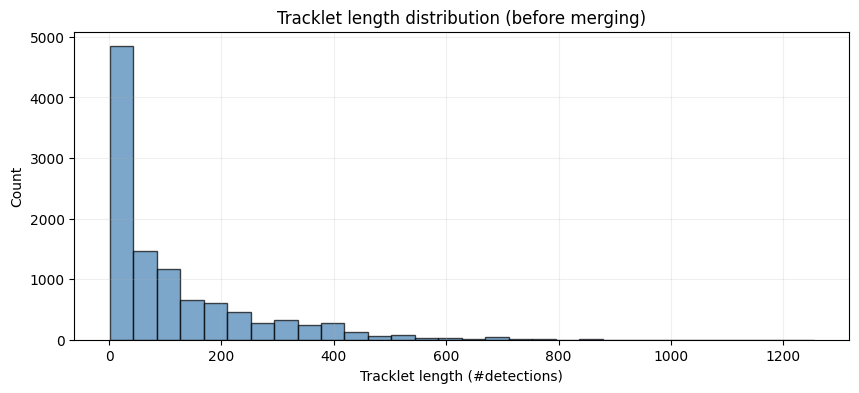

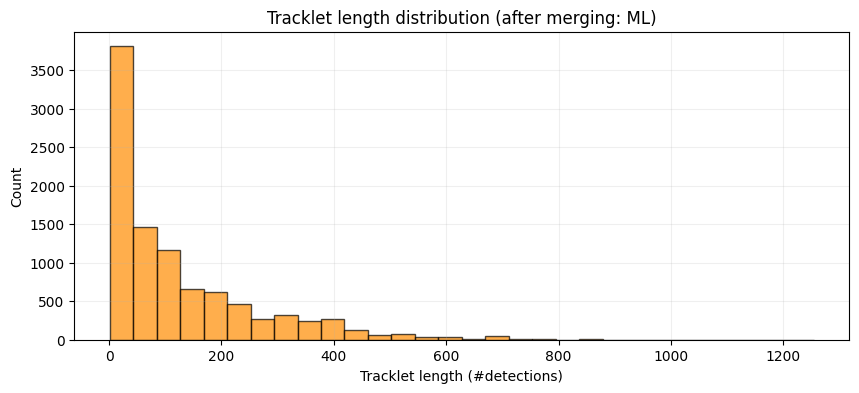

C:\Users\Admin\AppData\Local\Temp\ipykernel_7356\985938389.py:319: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby("Method")[["coverage_gt", "coverage_pred", "avg_gt_fragments"]]


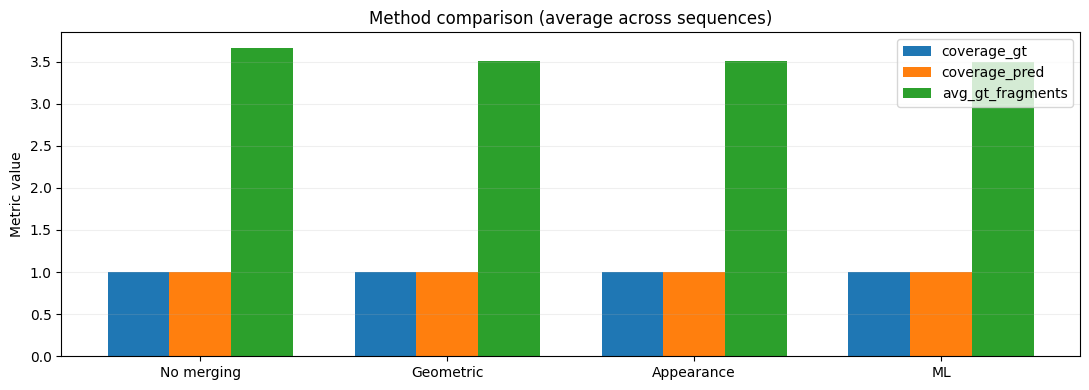


LogisticRegression coefficients (feature -> coef)


,feature,coef
7,hist_sim,9.797022
0,time_gap,-0.085975
6,speed_diff,-0.005545
1,dist_end_start,-0.004962
3,len2,-0.003204
2,len1,-0.003199
4,speed1,0.002911
5,speed2,0.000686


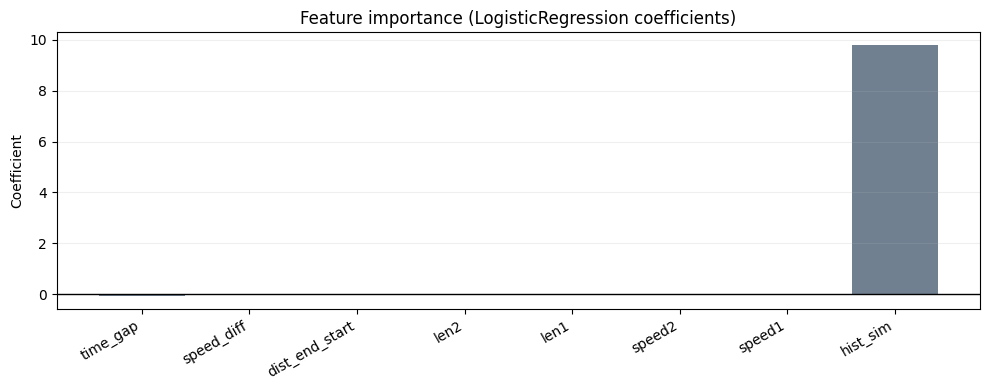


Done.


In [ ]:
# ===== One-shot run: train -> evaluate all methods -> save -> visualize =====

DATASET_ROOT = "VisDrone2019-MOT-train"  # update if needed
RESULTS_CSV_PATH = "results_visdrone_experiment.csv"

# Optional knobs (keep aligned with your current defaults)
DIST_THRESHOLD_TRACKLETS = 40.0
GEO_TIME_GAP = 5
GEO_DIST = 60.0
APP_TIME_GAP = 5
APP_DIST = 60.0
APP_MIN_HIST_SIM = 0.6
ML_PROB_THRESHOLD = 0.5
ML_MAX_TIME_GAP = 10
ML_MAX_DIST = 120.0


from pathlib import Path


def run_full_experiment_once(
    dataset_root: str = DATASET_ROOT,
    save_csv_path: str = RESULTS_CSV_PATH,
    plot_after_method: str = "ML",
) -> pd.DataFrame:
    """Execute the full experiment workflow and return the result table."""
    print("=" * 72)
    print("VisDrone Offline Tracklet Association | Full Experiment Runner")
    print("=" * 72)
    print("Dataset root:", dataset_root)

    if not os.path.isdir(dataset_root):
        raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

    # 1) Train/load dataset-level merge classifier
    print("\n[1/6] Training dataset-level LogisticRegression merge model...")
    merge_clf = train_merge_classifier_on_dataset(
        dataset_root,
        dist_threshold_for_tracklets=DIST_THRESHOLD_TRACKLETS,
        max_time_gap_pairs=30,
        max_dist_pairs=300.0,
        max_pairs_per_sequence=10_000,
    )

    # 2) Run experiment on all sequences and methods
    print("\n[2/6] Running multi-sequence experiment across 4 methods...")
    results_df = run_experiment_on_dataset(
        dataset_root,
        dist_threshold_for_tracklets=DIST_THRESHOLD_TRACKLETS,
        geo_time_gap_threshold=GEO_TIME_GAP,
        geo_distance_threshold=GEO_DIST,
        app_time_gap_threshold=APP_TIME_GAP,
        app_distance_threshold=APP_DIST,
        app_min_hist_similarity=APP_MIN_HIST_SIM,
        ml_prob_threshold=ML_PROB_THRESHOLD,
        ml_max_time_gap=ML_MAX_TIME_GAP,
        ml_max_dist=ML_MAX_DIST,
        merge_classifier=merge_clf,
    )

    if results_df.empty:
        print("\nNo rows produced. Check dataset layout and sequence/annotation matching.")
        return results_df

    # 3) Display core comparison tables
    print("\n[3/6] Method comparison table")
    comparison_cols = [
        "Sequence",
        "Method",
        "coverage_gt",
        "coverage_pred",
        "avg_gt_fragments",
        "avg_pred_id_switches",
    ]
    display(results_df[comparison_cols])

    # Helpful run diagnostics
    seq_processed = int(results_df["Sequence"].nunique())
    expected_rows = seq_processed * 4
    print(f"Processed sequences: {seq_processed}")
    print(f"Rows in results: {len(results_df)} (expected ~ {expected_rows} for 4 methods/sequence)")

    # 4) Save CSV
    print("\n[4/6] Saving CSV")
    save_path = Path(save_csv_path)
    results_df[comparison_cols].to_csv(save_path, index=False)
    print("Saved:", str(save_path.resolve()))

    # 5) Print summary metrics
    print("\n[5/6] Performance summary")
    print_performance_summary(results_df)

    # 6) Visualizations + feature importance
    print("\n[6/6] Plots and feature importance")
    plot_tracklet_length_distributions(
        results_df,
        dataset_root=dataset_root,
        dist_threshold_for_tracklets=DIST_THRESHOLD_TRACKLETS,
        after_method=plot_after_method,
    )
    plot_method_comparison_bars(results_df)
    print_and_plot_feature_importance(results_df.attrs.get("merge_classifier"))

    print("\nDone.")
    return results_df


# Execute once
results_df = run_full_experiment_once()


## Final scorecard (run separately)

Run the next cell **after** `results_df` is available. This creates a report-friendly scorecard with:
- Mean and std per method
- Best/worst sequence per metric
- A compact composite ranking


FINAL SCORECARD

[1] Mean ± Std by Method


,Method,coverage_gt_mean,coverage_gt_std,coverage_pred_mean,coverage_pred_std,avg_gt_fragments_mean,avg_gt_fragments_std,avg_pred_id_switches_mean,avg_pred_id_switches_std
0,No merging,1.0,0.0,1.0,0.0,3.6632,3.1196,2.3393,1.2157
1,Geometric,1.0,0.0,1.0,0.0,3.5019,2.9213,2.4351,1.2462
2,Appearance,1.0,0.0,1.0,0.0,3.5028,2.9215,2.4313,1.2428
3,ML,1.0,0.0,1.0,0.0,3.4958,2.8536,2.4740,1.2898



[2] Best / Worst Sequence per Metric


,Method,Metric,Best_Sequence,Best_Value,Worst_Sequence,Worst_Value
0,No merging,coverage_gt,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000
1,No merging,coverage_pred,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000
2,No merging,avg_gt_fragments,uav0000361_02323_v,1.157025,uav0000281_00460_v,15.273292
3,No merging,avg_pred_id_switches,uav0000266_04830_v,1.000000,uav0000278_00001_v,6.811558
4,Geometric,coverage_gt,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000
5,Geometric,coverage_pred,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000
6,Geometric,avg_gt_fragments,uav0000266_04830_v,1.000000,uav0000281_00460_v,14.801242
7,Geometric,avg_pred_id_switches,uav0000266_04830_v,1.000000,uav0000278_00001_v,6.875635
8,Appearance,coverage_gt,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000
9,Appearance,coverage_pred,uav0000013_00000_v,1.000000,uav0000013_00000_v,1.000000



[3] Composite Ranking (higher is better)


,Method,coverage_gt,coverage_pred,avg_gt_fragments,avg_pred_id_switches,composite_score
0,Appearance,1.0,1.0,3.502807,2.431335,0.406586
1,Geometric,1.0,1.0,3.501884,2.435112,0.406300
2,ML,1.0,1.0,3.495808,2.473997,0.403019
3,No merging,1.0,1.0,3.663195,2.339311,0.399749


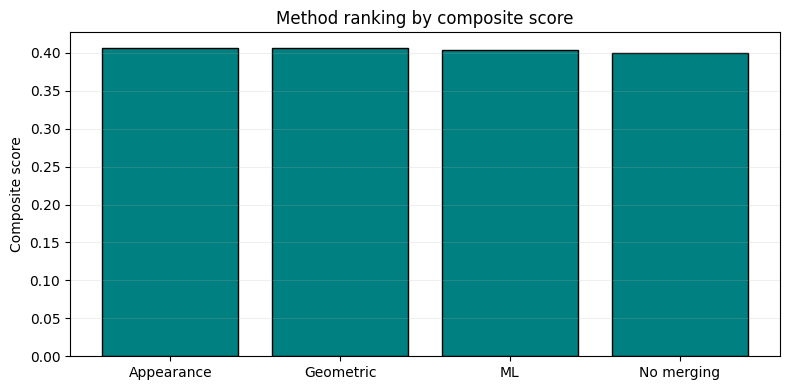

In [ ]:
# ===== Final scorecard cell (standalone; run after experiment) =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_final_scorecard(df_results: pd.DataFrame):
    """Create report-ready scorecard tables from experiment results."""
    required_cols = {
        "Sequence",
        "Method",
        "coverage_gt",
        "coverage_pred",
        "avg_gt_fragments",
        "avg_pred_id_switches",
    }
    missing = required_cols - set(df_results.columns)
    if missing:
        raise ValueError(f"df_results is missing columns: {sorted(missing)}")

    # 1) Mean ± std by method
    agg = (
        df_results.groupby("Method", observed=False)[
            ["coverage_gt", "coverage_pred", "avg_gt_fragments", "avg_pred_id_switches"]
        ]
        .agg(["mean", "std"])
        .round(4)
    )

    # Flatten multi-index columns for readability
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    agg = agg.reset_index()

    # 2) Best / worst sequence per metric for each method
    rows = []
    metric_specs = [
        ("coverage_gt", True),
        ("coverage_pred", True),
        ("avg_gt_fragments", False),
        ("avg_pred_id_switches", False),
    ]

    for method, g in df_results.groupby("Method", observed=False):
        for metric, higher_is_better in metric_specs:
            idx_best = g[metric].idxmax() if higher_is_better else g[metric].idxmin()
            idx_worst = g[metric].idxmin() if higher_is_better else g[metric].idxmax()
            best_row = g.loc[idx_best]
            worst_row = g.loc[idx_worst]
            rows.append(
                {
                    "Method": method,
                    "Metric": metric,
                    "Best_Sequence": best_row["Sequence"],
                    "Best_Value": float(best_row[metric]),
                    "Worst_Sequence": worst_row["Sequence"],
                    "Worst_Value": float(worst_row[metric]),
                }
            )

    extremes_df = pd.DataFrame(rows)

    # 3) Composite score (higher is better)
    #    +coverage_gt +coverage_pred -fragmentation_penalty -id_switch_penalty
    comp = (
        df_results.groupby("Method", observed=False)[
            ["coverage_gt", "coverage_pred", "avg_gt_fragments", "avg_pred_id_switches"]
        ]
        .mean()
        .reset_index()
    )
    comp["composite_score"] = (
        0.40 * comp["coverage_gt"]
        + 0.40 * comp["coverage_pred"]
        - 0.10 * np.maximum(0.0, comp["avg_gt_fragments"] - 1.0)
        - 0.10 * np.maximum(0.0, comp["avg_pred_id_switches"] - 1.0)
    )
    ranking_df = comp.sort_values("composite_score", ascending=False).reset_index(drop=True)

    return agg, extremes_df, ranking_df


def print_final_scorecard(df_results: pd.DataFrame):
    agg, extremes_df, ranking_df = build_final_scorecard(df_results)

    print("=" * 72)
    print("FINAL SCORECARD")
    print("=" * 72)

    print("\n[1] Mean ± Std by Method")
    display(agg)

    print("\n[2] Best / Worst Sequence per Metric")
    display(extremes_df)

    print("\n[3] Composite Ranking (higher is better)")
    display(ranking_df)

    # Optional compact bar chart for composite ranking
    plt.figure(figsize=(8, 4))
    plt.bar(ranking_df["Method"].astype(str), ranking_df["composite_score"], color="teal", edgecolor="black")
    plt.title("Method ranking by composite score")
    plt.ylabel("Composite score")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


# Run scorecard now (expects results_df from previous experiment cell)
if "results_df" not in globals() or results_df is None or len(results_df) == 0:
    print("results_df not found or empty. Run the experiment cell first.")
else:
    print_final_scorecard(results_df)
